# Explanation with undercutting and overdetermination: a synthetic experiment


In this notebook, we build off the existing counterexamples to the but-for clause as an explanation tool. The initial intuition one might have is the following:

$X=x$ is responsible for $Y=y$ just in case $Y$ would have been different had we intervened on $X$ to be different, i.e. if $Y_{x'} = y'$ for some $x' \neq x, y' \neq y$. 

A typical counterexample to this is cast in terms of categorical variables: Sally and Billy pick up stones and throw them at a bottle. Sally’s stone gets there first, shattering the bottle. Both throws are perfectly accurate, so Billy’s stone would have shattered the bottle had it not been preempted by Sally’s throw. The intuition is that Sally's throw is responsible for the shattering, but not so Billy's. However, it is false that had Sally not thrown the stone, the bottle would not have shattered, so the simple counterfactual condition fails.

What we want to investigate in this notebook is the performance of `ThinSearch` in the context of a synthetic generalization of this problem. Suppose we use continuous variables in a model with a similar overdetermination and undercutting structure. Is the tool capable of meeting our expectations when it comes to the responsibility attribution? 

The answer is positive. We first introduce the model, then we illustrate the intuitive desiderata using three concrete examples. Finally, we estimate how often the desiderata are met when we provide 500 local explanations for events generated using the same generative process.

### Setup

In [1]:
import os

import graphviz
import matplotlib.pyplot as plt
import pandas as pd
import pyro
import pyro.distributions as dist
import seaborn as sns
import torch
from IPython.display import display

from pci.explanation.regime import condition_on_interventional_regime
from pci.explanation.scores import abs_diff_score
from pci.explanation.searchable import SearchableModel
from pci.explanation.thin_search import ThinSearchSampler
from pci.tools.find_root import find_repo_root

smoke_test = "CI" in os.environ


n_size = 5 if smoke_test else 500
num_search_samples = 10 if smoke_test else 5000

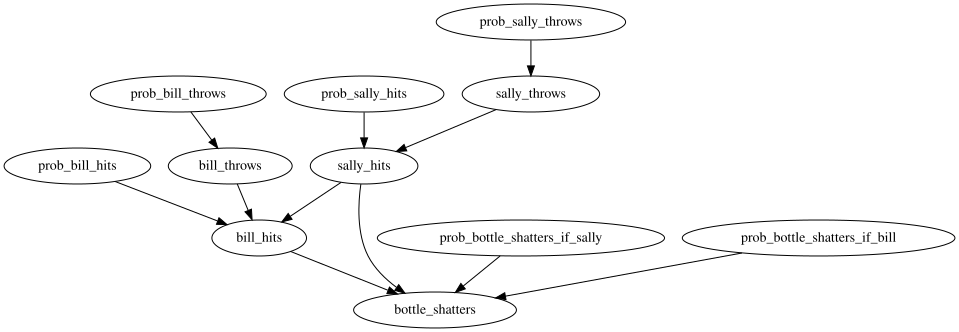

In [2]:
# the original model as a reminder


def stones_model():
    prob_sally_throws = pyro.sample("prob_sally_throws", dist.Beta(1, 1))
    prob_bill_throws = pyro.sample("prob_bill_throws", dist.Beta(1, 1))
    prob_sally_hits = pyro.sample("prob_sally_hits", dist.Beta(1, 1))
    prob_bill_hits = pyro.sample("prob_bill_hits", dist.Beta(1, 1))
    prob_bottle_shatters_if_sally = pyro.sample(
        "prob_bottle_shatters_if_sally", dist.Beta(1, 1)
    )
    prob_bottle_shatters_if_bill = pyro.sample(
        "prob_bottle_shatters_if_bill", dist.Beta(1, 1)
    )

    sally_throws = pyro.sample("sally_throws", dist.Bernoulli(prob_sally_throws))
    bill_throws = pyro.sample("bill_throws", dist.Bernoulli(prob_bill_throws))

    # if Sally throws, she hits with probability prob_sally_hits
    # hits with pr=0 otherwise
    new_shp = torch.where(sally_throws == 1, prob_sally_hits, 0.0)

    sally_hits = pyro.sample("sally_hits", dist.Bernoulli(new_shp))

    # if Bill throws, he hits with probability prob_bill_hits
    # if sally doesn't hit sooner,
    # misses otherwise
    new_bhp = torch.where(
        bill_throws.bool() & (~sally_hits.bool()),
        prob_bill_hits,
        torch.tensor(0.0),
    )

    bill_hits = pyro.sample("bill_hits", dist.Bernoulli(new_bhp))

    # you can use a analogous move to model the bottle shattering
    # if being hit by a stone doesn't deterministically
    # shatter the bottle
    new_bsp = torch.where(
        bill_hits.bool(),
        prob_bottle_shatters_if_bill,
        torch.where(
            sally_hits.bool(),
            prob_bottle_shatters_if_sally,
            torch.tensor(0.0),
        ),
    )

    bottle_shatters = pyro.sample("bottle_shatters", dist.Bernoulli(new_bsp))

    return {
        "sally_throws": sally_throws,
        "bill_throws": bill_throws,
        "sally_hits": sally_hits,
        "bill_hits": bill_hits,
        "bottle_shatters": bottle_shatters,
    }


pyro.render_model(stones_model)

The way we generalize is as follows. The input and output variables are continuous. The A variables are like Sally's throw: they have an unblocked impact on the outcome. The C variables are like Billy's throw: if their linear combination is high enough, they are active and can have an impact on the outcome. Otherwise, their impact is blocked. B and D are like `sally_hits` and `bill_hits`, except continuous, and E is some final outcome, except now we don't use a disjunction, but rather addition.

\begin{align*}
\text{For } i = 0, 1, 2: &  \\
&\quad A_i \sim \mathcal{N}(0, 1), \\
&\quad C_i \sim \mathcal{N}(0, 1), \\
\text{and}  & \\
 B & = 0 \cdot A_0 + 5 \cdot A_1 + 10 \cdot A_2, \\

 cs\_dot & = 0 \cdot C_0 + 5 \cdot C_1 + 10 \cdot C_2, \\

 cs\_win &= \mathbf{1}\{ cs\_dot > B \}, \\

 D & = cs\_dot \cdot cs\_win, \\

 E& = B + D.
\end{align*}



In [3]:
def synthetic_model(
    kwargs_iterable=[
        {"observations_dict": None, "n_size": n_size},
        dict(),
        dict(),
    ],
):
    # for compatibility with a structured model, we assume it takes kwargs_iterable,
    # normally expected to be passed to a model built using ModelComposer
    batch_size = kwargs_iterable[0]["n_size"]

    with pyro.plate("sample", size=batch_size, dim=-3):
        As = {}
        Cs = {}

        for i in range(3):
            As[f"A{i}"] = pyro.sample(
                f"A{i}",
                dist.Normal(0, 1),
            )

            Cs[f"C{i}"] = pyro.sample(
                f"C{i}",
                dist.Normal(0, 1),
            )

        B = pyro.deterministic("B", 0 * As["A0"] + 5 * As["A1"] + 10 * As["A2"])

        cs_dot = 0 * Cs["C0"] + 5 * Cs["C1"] + 10 * Cs["C2"]

        cs_win = pyro.deterministic("cs_win", (cs_dot > B).float())

        D = pyro.deterministic("D", cs_dot * cs_win)

        E = pyro.deterministic("E", B + D)

    return {**As, "B": B, **Cs, "cs_dot": cs_dot, "cs_win": cs_win, "D": D, "E": E}


torch.manual_seed(0)
factual_dict = synthetic_model()


factual_dict.keys()

dict_keys(['A0', 'A1', 'A2', 'B', 'C0', 'C1', 'C2', 'cs_dot', 'cs_win', 'D', 'E'])

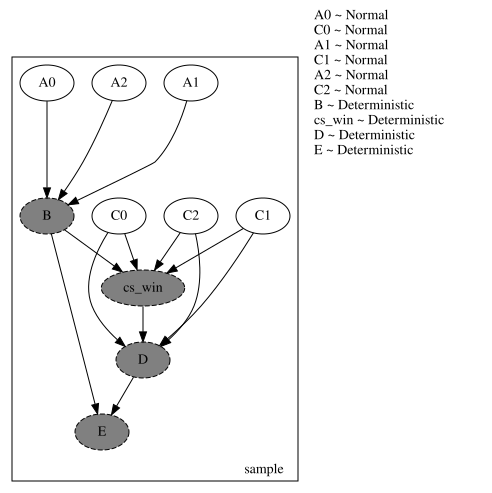

In [4]:
kwargs_iterable_for_rendering = [{"observations_dict": None, "n_size": 1}, {}, {}]


dot = pyro.render_model(
    synthetic_model,
    model_args=(kwargs_iterable_for_rendering,),
    render_distributions=True,
    render_params=True,
    render_deterministic=True,
)

display(dot)

# this is the Pyro rendering, we'll do a more informative one below

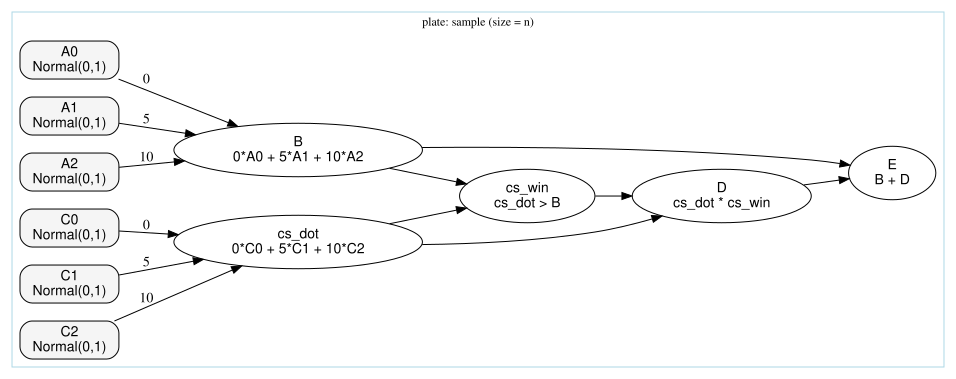

'/home/rafal/s76projects/explainable_paper/docs/source/figures/synthetic_causal_model.png'

In [5]:
# a more pleasant rendering
root = find_repo_root()
figure_dir = os.path.join(root, "docs/source/figures")
model_figure_path = os.path.join(figure_dir, "synthetic_causal_model")


def render_all_inside_plate(filename=None, view=False):
    g = graphviz.Digraph("synthetic_model_plate", format="png")
    g.attr(rankdir="LR", fontsize="12")
    g.node_attr.update(
        shape="box", style="rounded,filled", fillcolor="#f5f5f5", fontname="Helvetica"
    )

    with g.subgraph(name="cluster_sample") as c:
        c.attr(label="plate: sample (size = n)", color="lightblue")

        for i in range(3):
            c.node(f"A{i}", label=f"A{i}\nNormal(0,1)")
        for i in range(3):
            c.node(f"C{i}", label=f"C{i}\nNormal(0,1)")

        c.node("B", label="B\n 0*A0 + 5*A1 + 10*A2", shape="ellipse", fillcolor="white")
        c.node(
            "cs_dot",
            label="cs_dot\n 0*C0 + 5*C1 + 10*C2",
            shape="ellipse",
            fillcolor="white",
        )
        c.node(
            "cs_win", label="cs_win\n cs_dot > B", shape="ellipse", fillcolor="white"
        )
        c.node("D", label="D\n cs_dot * cs_win", shape="ellipse", fillcolor="white")
        c.node("E", label="E\n B + D", shape="ellipse", fillcolor="white")

        c.edge("A0", "B", label="0")
        c.edge("A1", "B", label="5")
        c.edge("A2", "B", label="10")

        c.edge("C0", "cs_dot", label="0")
        c.edge("C1", "cs_dot", label="5")
        c.edge("C2", "cs_dot", label="10")

        c.edge("B", "cs_win")
        c.edge("cs_dot", "cs_win")
        c.edge("cs_dot", "D")
        c.edge("cs_win", "D")
        c.edge("B", "E")
        c.edge("D", "E")

    if filename:
        g.render(filename, cleanup=True, view=view)

    return g


dot = render_all_inside_plate()
display(dot)

dot.format = "png"
dot.render(
    filename=model_figure_path, cleanup=True
)  # writes synthetic_model_render.png

### Evaluation on concrete examples

We used the generative model to obtain 500 synthetic observations, to play the role of 500 synthetic data points, for which we will be providing and evaluating explanations. Now we'll find three typical examples:

- C not activated, A1 isn't much bigger (in terms of absolute value) than A2
- C activated, but C2 is much smaller than C1
- C activated, A1 isn't much bigger (in terms of absolute value) than A2, C2 is somewhat bigger than C1, C1 is smaller than C1

Later on, we will perform batch evaluation without those assumptions; for now, we want to look at particular cases and reflect on what we expect.

In [6]:
def factual_df(index=0):
    return pd.DataFrame(
        {k: v[index, 0, 0].numpy().flatten() for k, v in factual_dict.items()}
    )


indices = []

# example: no C activation, A1 is not (much bigger than A2)
for i in range(n_size):
    df = factual_df(i)
    if not df["cs_win"].item():
        if df["A1"].abs().item() * 4 < df["A2"].abs().item():
            indices.append(i)
            break

# example: C activation, but C2 much lower absolute value than C1
for i in range(n_size):
    df = factual_df(i)
    if df["cs_win"].item() and (df["C2"].abs().item() > 0.5):
        if df["C2"].abs().item() * 3 < (df["C1"].abs().item() * 2):
            indices.append(i)
            break

# example: C activation, and C2 slightly higher absolute value than C1, which in turn is larger than C0
# A1 not (much bigger than A2)
for i in range(n_size):
    df = factual_df(i)
    if df["cs_win"].item() and (df["C2"].abs().item() > 0.5):
        if df["A1"].abs().item() * 4 < df["A2"].abs().item():
            if (df["C2"].abs().item() - (df["C1"].abs().item()) > 0) and (
                df["C2"].abs().item() / (df["C1"].abs().item())
            ) < 3:
                if df["C0"].abs().item() < df["C1"].abs().item():
                    indices.append(i)
                    break

# here for smoke test
if len(indices) < 3:
    print("Could not find all examples, defaulting to first 3")
    indices = list(range(3))

print(indices)
for i in indices:
    display(factual_df(i))

[19, 4, 65]


,A0,A1,A2,B,C0,C1,C2,cs_dot,cs_win,D,E
0,0.793508,-0.383653,1.879332,16.875053,-0.056879,-0.260818,0.800342,6.699331,0.0,0.0,16.875053


,A0,A1,A2,B,C0,C1,C2,cs_dot,cs_win,D,E
0,0.84871,-0.030764,-0.51011,-5.254921,-1.453241,-2.487876,0.773025,-4.709127,1.0,-4.709127,-9.964048


,A0,A1,A2,B,C0,C1,C2,cs_dot,cs_win,D,E
0,0.919971,-0.032247,0.296999,2.808753,0.323648,1.280464,2.121044,27.612764,1.0,27.612764,30.421516


Say we denote the mean causal impact of a variable $V$ by $ci(V)$. We do not expect to see zero estimates for irrelevant properties, as the score also results from sampling other potential causes and witnesses, but we do expect the following qualitative/comparative statements to hold:

- For each of the three observations, $ci(A0) < ci(A1) < ci(A2)$, with $ci(A1)$ and $ci(A2)$ to be closer to each other for index 6, as while $A2$ has a higher coefficient, its value is three times lower than that of $A1$.
- For the first, variables $C$ are supposed to be blocked, so we expect $ci(C1) \approx ci(C2) \approx ci(C3) \approx ci(A0)$ (because $A0$ having 0 coefficient is expected to have no impact as well).
- For the second, we expect $ci(C0)< ci(C1), ci(C2)$, but also we notice that $abs(C1)/abs(C2)$ is larger than the corresponding proportionate difference in the coefficients, so we expect $ci(C1)$ to not be far off from $ci(C2)$, potentially even being a bit higher.
- For the last one, we expect $ci(C1)$ to be definitely lower than $ci(C2)$, as not only the coefficient for $ci(C2)$ is higher, but also so is the value of $C2$.

Let's use our tool to compute causal impact scores.

In [7]:
small_factual_dict = {
    k: v
    for k, v in factual_dict.items()
    if k in ["A0", "A1", "A2", "C0", "C1", "C2", "E"]
}

factual_structured_dict = {"continuous": small_factual_dict, "categorical": {}}

toy_searchable = SearchableModel(
    structured_model=synthetic_model,
    sites_of_interest=list(small_factual_dict.keys()),
    suspects=["A0", "A1", "A2", "C0", "C1", "C2"],
    outcome_variable="E",
)

search_sampler = ThinSearchSampler(
    structured_model=toy_searchable,
    conditioned_alternatives=True,
    factual_exclusion=True,
)

results = search_sampler.sample(
    factual_structured_dict,
    num_samples=num_search_samples,
)

  0%|          | 0/5000 [00:00<?, ?it/s]

  1%|          | 37/5000 [00:00<00:13, 366.29it/s]

  1%|▏         | 74/5000 [00:00<00:13, 359.52it/s]

  2%|▏         | 110/5000 [00:00<00:17, 287.13it/s]

  3%|▎         | 142/5000 [00:00<00:16, 295.58it/s]

...

100%|█████████▉| 4981/5000 [00:56<00:00, 47.37it/s]

100%|█████████▉| 4986/5000 [00:56<00:00, 47.23it/s]

100%|█████████▉| 4991/5000 [00:56<00:00, 47.85it/s]

100%|█████████▉| 4996/5000 [00:56<00:00, 46.90it/s]

100%|██████████| 5000/5000 [00:56<00:00, 87.81it/s]

In [8]:
conditioned_samples = {}
suspect_scores = {}
for suspect in ["A0", "A1", "A2", "C0", "C1", "C2"]:
    conditioned_samples[suspect] = condition_on_interventional_regime(
        results_dictionary=results,  # type: ignore
        reference_variable_names=[suspect],
        antecedent_regimes={suspect: True},
        witness_regimes={suspect: False},
    )

    suspect_suff = conditioned_samples[suspect]["regime_sufficiency"][suspect].detach()
    suspect_nec = conditioned_samples[suspect]["regime_necessity"][suspect].detach()

    e_suff = conditioned_samples[suspect]["regime_sufficiency"]["E"].detach()
    e_nec = conditioned_samples[suspect]["regime_necessity"]["E"]

    scores = abs_diff_score(
        suff_outcomes=e_suff,
        nec_outcomes=e_nec,
        factual_outcomes=small_factual_dict["E"].detach(),
    )
    suspect_scores[suspect] = scores

Let's take a look at the causal impact score distributions for the three selected rows, with mean scores, in light of our expectations. Each column corresponds to one of the three selected observations. The top histograms are those of causal impact scores for $A0, A1$, and $A2$, and the bottom histograms are for $C0, C1$, and $C2$.

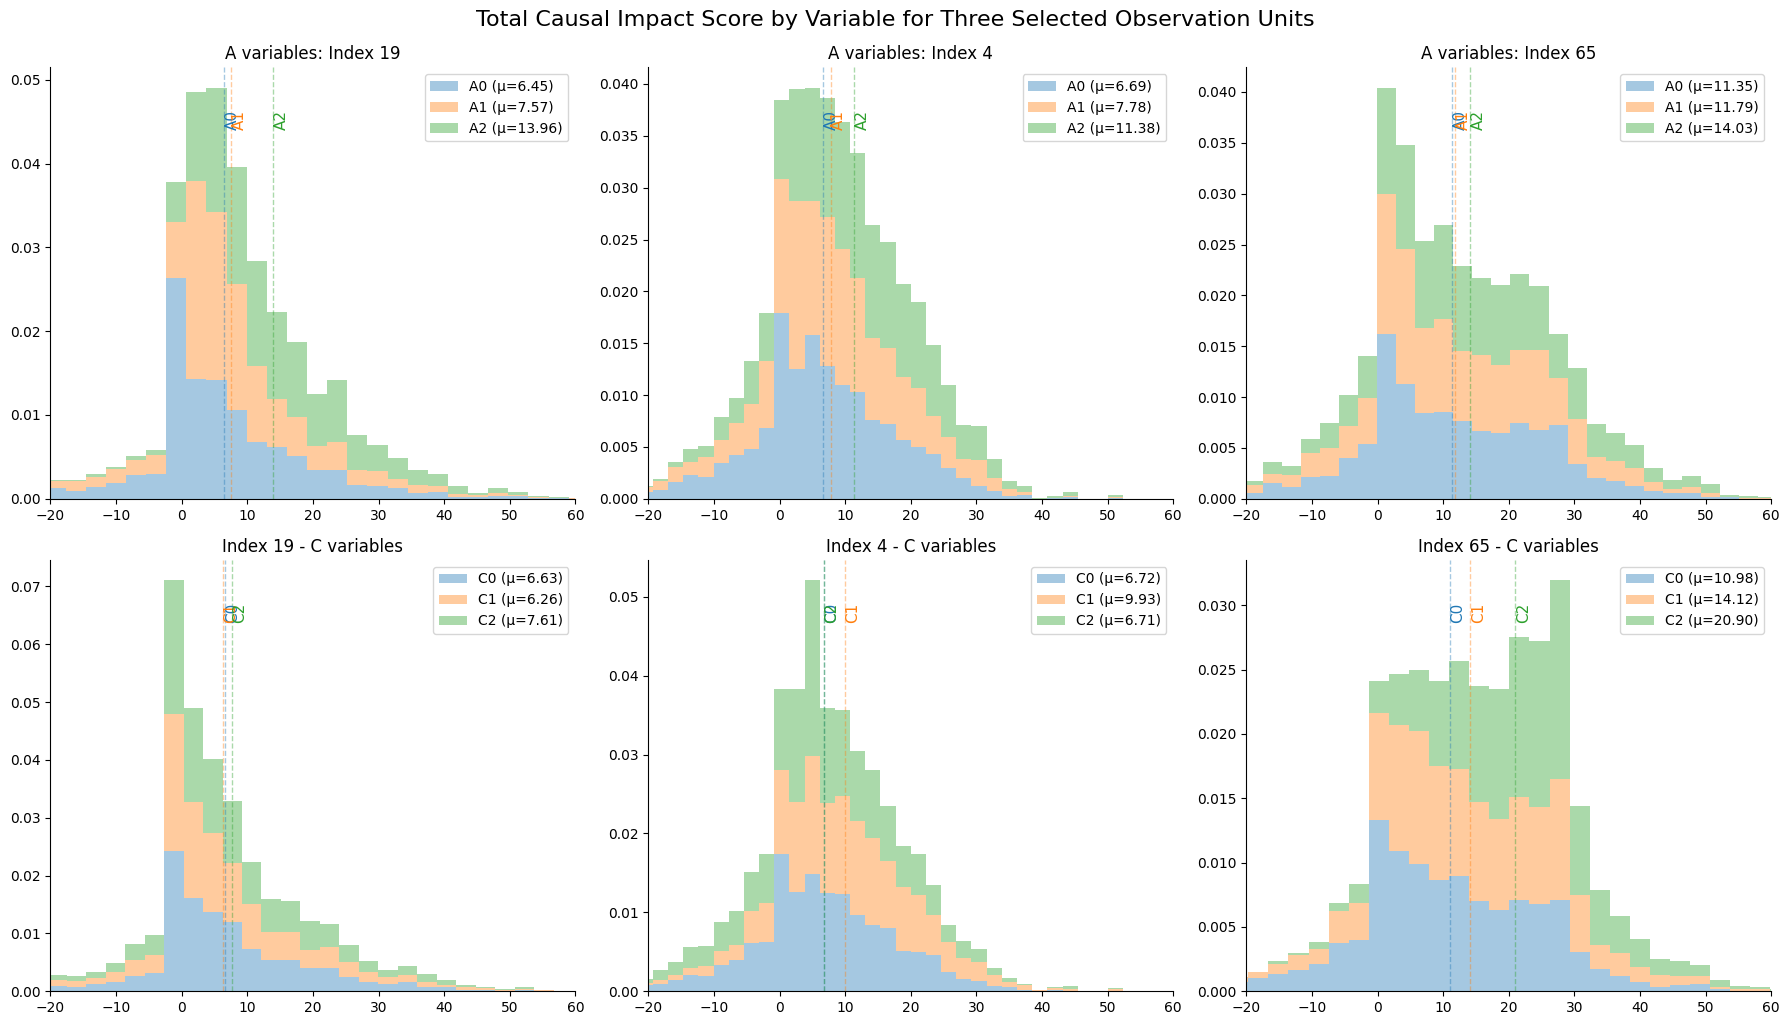

In [9]:
variables = ["A0", "A1", "A2", "C0", "C1", "C2"]

a_vars = ["A0", "A1", "A2"]
c_vars = ["C0", "C1", "C2"]

properties_total_scores: dict = {}
for index in indices:
    properties_total_scores[index] = {}
    for variable in variables:
        properties_total_scores[index][variable] = suspect_scores[variable]["total"][
            :, index, 0, 0
        ]


fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for i_reset in range(len(indices)):
    axes[0, i_reset].set_title(f"A variables: Index {indices[i_reset]}")

    ax = axes[0, i_reset]
    ax.set_xlim(-20, 60)
    values = [properties_total_scores[indices[i_reset]][var] for var in a_vars]
    means = [v.nanmean().item() for v in values]

    labels = [f"{var} (μ={mean_val:.2f})" for var, mean_val in zip(a_vars, means)]

    n, bins, patches = ax.hist(
        values, bins=40, alpha=0.4, stacked=True, density=True, label=labels
    )
    colors = [p[0].get_facecolor() for p in patches]

    for var, mean_val, col in zip(a_vars, means, colors):
        ax.axvline(mean_val, linestyle="--", linewidth=1, color=col)
        ax.text(
            mean_val * 1.01,
            ax.get_ylim()[1] * 0.9,
            var,
            rotation=90,
            va="top",
            fontsize=11,
            color=col,
            alpha=1,
        )

    ax.legend()

    axes[1, i_reset].set_xlim(-20, 60)
    ax = axes[1, i_reset]
    values = [properties_total_scores[indices[i_reset]][var] for var in c_vars]
    means = [v.nanmean().item() for v in values]
    labels = [f"{var} (μ={mean_val:.2f})" for var, mean_val in zip(c_vars, means)]
    n, bins, patches = ax.hist(
        values, bins=40, alpha=0.4, stacked=True, density=True, label=labels
    )
    colors = [p[0].get_facecolor() for p in patches]
    for var, mean_val, col in zip(c_vars, means, colors):
        ax.axvline(mean_val, linestyle="--", linewidth=1, color=col)
        ax.text(
            mean_val * 1.01,
            ax.get_ylim()[1] * 0.9,
            var,
            rotation=90,
            va="top",
            fontsize=11,
            color=col,
            alpha=1,
        )

    ax.legend()


for i_reset in range(len(indices)):
    axes[1, i_reset].set_title(f"Index {indices[i_reset]} - C variables")


sns.despine()
plt.tight_layout()
plt.suptitle(
    "Total Causal Impact Score by Variable for Three Selected Observation Units",
    fontsize=16,
    y=1.02,
)
plt.show()

### Qualitative requirements: batch evaluation

Visual inspection suggests the desiderata are satisfied for the three cases. Now, let's see how often they are satisfied in the whole sample when we try to explain each of the 500 events.

In [10]:
factual_dict.keys()

cs_win = factual_dict["cs_win"].flatten().numpy()
cs_1 = factual_dict["C1"].flatten().numpy()
cs_2 = factual_dict["C2"].flatten().numpy()

total_means = {
    key: suspect_scores[key]["total"].nanmean(dim=0).flatten() for key in variables
}

total_means_df = pd.DataFrame(total_means)

total_means_df["cs_win"] = cs_win

# these are factual values, not scores
total_means_df["cs_1"] = cs_1
total_means_df["cs_2"] = cs_2

total_means_df_cs0 = total_means_df[total_means_df["cs_win"] == 0]
total_means_df_cs1 = total_means_df[total_means_df["cs_win"] == 1]
c1_higher_than_c2 = total_means_df_cs1[
    total_means_df_cs1["C1"] > total_means_df_cs1["C2"]
]

First, let's take a look at the mean total scores for properties, ordered first by whether we're dealing with `_0, _1, _2` variable, and then by whether it's `A_` or `C_`. For A variables, we expect the means to increase as we move right, for C, we expect them to increase as we move from left to right if they are activated (histogram on the right), but not so if they are not (histogram on the left).

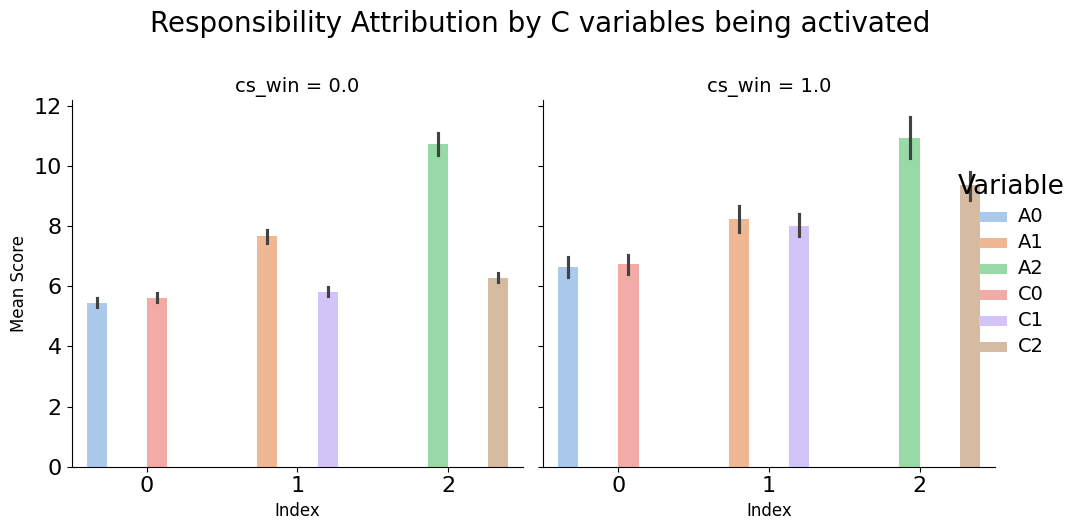

In [11]:
plot_df = total_means_df.melt(
    id_vars=["cs_win", "cs_1", "cs_2"],
    value_vars=["A0", "A1", "A2", "C0", "C1", "C2"],
    var_name="Variable",
    value_name="MeanScore",
)
plot_df["Group"] = plot_df["Variable"].str[0]  # 'A' or 'C'
plot_df["Index"] = plot_df["Variable"].str[1]


g = sns.catplot(
    data=plot_df,
    x="Index",
    y="MeanScore",
    hue="Variable",
    col="cs_win",
    kind="bar",
    palette="pastel",
    height=5,
    aspect=1,
)

g.set_titles("cs_win = {col_name}", size=14)

g.set_axis_labels("Index", "Mean Score")
g.set_xlabels("Index", fontsize=12)
g.set_ylabels("Mean Score", fontsize=12)

g.fig.suptitle(
    "Responsibility Attribution by C variables being activated",
    fontsize=20,
    y=1.03,
)
for ax in g.axes.flat:
    ax.tick_params(axis="x", labelsize=16)
    ax.tick_params(axis="y", labelsize=16)

g._legend.set_title("Variable")
for t in g._legend.texts:
    t.set_fontsize(14)
g._legend.get_title().set_fontsize(19)

g.fig.subplots_adjust(top=0.85)

figure_path = os.path.join(
    figure_dir, "synthetic_causal_model_responsibility_attribution.png"
)
g.savefig(figure_path, dpi=300)

When `cs_win=0`, the C variables are not activated, and so we expect total scores for all of them to be similar (red, violet, dark brown on the left-hand side). We still expect the scores for A0, A1, A2 generally to increase independently of what happens with the C variables, which we see on both sides (blue, light brown, and green on both sides). We also expect the scores for Cs to increase if they are activated (red, violet, dark brown on the right-hand side). These expectations are satisfied. Now, for the qualitative check, let's see how often the requirements end up satisfied.

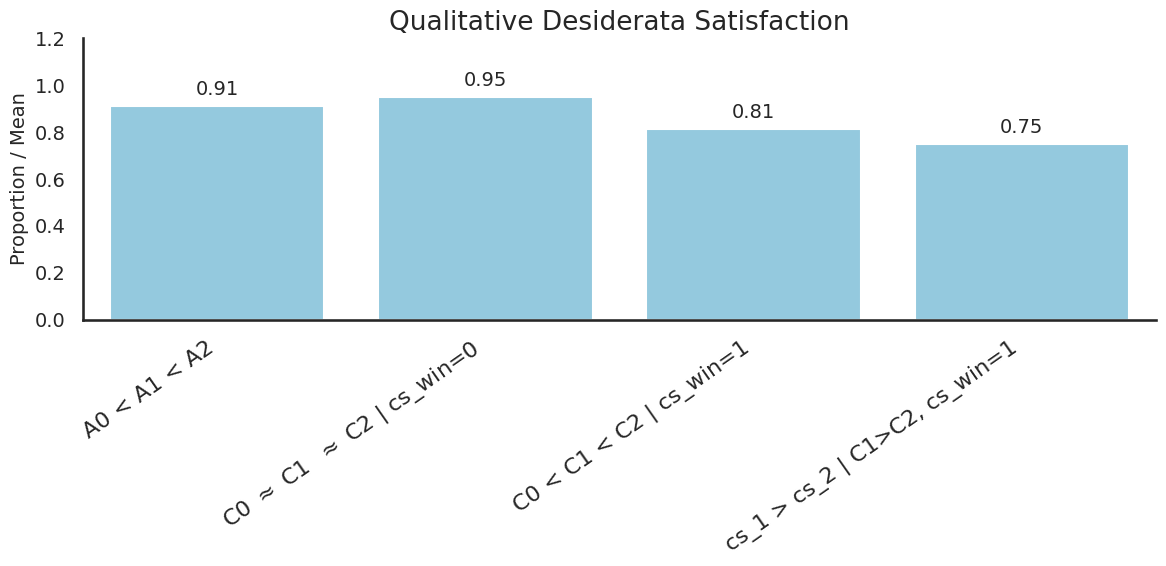

In [12]:
sns.set(style="white", context="talk")

summary_means = {
    "A0 < A1 < A2": (
        (total_means_df["A0"] < total_means_df["A1"])
        & (total_means_df["A1"] < total_means_df["A2"])
    ).mean(),
    "C0 $\\approx$ C1  $\\approx$ C2 | cs_win=0": (
        ((total_means_df_cs0["C0"] - total_means_df_cs0["C1"]).abs() < 2)
        & ((total_means_df_cs0["C1"] - total_means_df_cs0["C2"]).abs() < 2)
    ).mean(),
    "C0 < C1 < C2 | cs_win=1": (
        (total_means_df_cs1["C0"] < total_means_df_cs1["C1"])
        & (total_means_df_cs1["C1"] < total_means_df_cs1["C2"])
    ).mean(),
    "cs_1 > cs_2 | C1>C2, cs_win=1": (
        c1_higher_than_c2["cs_1"].abs() > c1_higher_than_c2["cs_2"].abs()
    ).mean(),
}
summary_labels = list(summary_means.keys())
summary_values = list(summary_means.values())

labels = list(summary_means.keys())
values = list(summary_means.values())

plt.figure(figsize=(12, 6))

sns.barplot(x=labels, y=values, color="skyblue")

plt.ylabel("Proportion / Mean", fontsize=14)
plt.title("Qualitative Desiderata Satisfaction", fontsize=19)
plt.ylim(0, 1.2)


for i, val in enumerate(values):
    plt.text(i, val + 0.03, f"{val:.2f}", ha="center", va="bottom", fontsize=14)

plt.xticks(rotation=35, ha="right", fontsize=16)
plt.yticks(fontsize=14)
plt.tight_layout()
sns.despine()

figure_path = os.path.join(figure_dir, "synthetic_causal_model_summary.png")
plt.savefig(figure_path, dpi=300)
plt.show()

Most of the time, the ordering of the scores for A variables agrees with the ordering of the coefficients. Most of the time close proximity of scores for inactive C variables is quite high; most often, the ordering for active C variables agrees with the ordering of the coefficients. We do not, however, want an explanation to track coefficients only, which, for instance, is illustrated by the last statement: if scores are reversed, this is mostly due to the disparate direction of the difference between the variable values.